# 🏆 Notebook 4 — Ensemble + Hyperparameter Tuning
**Malicious URL Detection | ISCX-URL2016**

This notebook implements:
- **Stacking Ensemble** (meta-learner on top of ML + DL base models)
- **Binary Specialist Ensemble** — one RF per attack class, scores fed as meta-features
- **Optuna** hyperparameter tuning for LightGBM (the strongest single model)
- **Final Champion** comparison and export



## 0 · Setup

In [ ]:
!pip install -q optuna lightgbm xgboost imbalanced-learn scikit-learn pytorch-tabnet

from google.colab import drive
drive.mount('/content/drive')

import os, json, pickle, warnings
warnings.filterwarnings('ignore')

SAVE_DIR  = '/content/drive/MyDrive/ESI TPs/sec_miniProject/Detection_of_Malicious_URLs/processed/'
MODEL_DIR = '/content/drive/MyDrive/ESI TPs/sec_miniProject/Detection_of_Malicious_URLs/modelsv2/'
os.makedirs(MODEL_DIR, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.8 MB/s eta 0:00:00
Mounted at /content/drive


## 1 · Load Data & Base Models

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

df = pd.read_csv(SAVE_DIR + 'processed_data.csv')
with open(SAVE_DIR + 'label_map.json') as f:
    label_map = {int(k): v for k, v in json.load(f).items()}
n_classes = len(label_map)

X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_tr_sm, y_tr_sm = smote.fit_resample(X_train_sc, y_train)

print(f'Train: {X_tr_sm.shape} | Test: {X_test_sc.shape}')

# Load saved ML models
with open(MODEL_DIR + 'ml_models.pkl', 'rb') as f:
    ml_models = pickle.load(f)
rf    = ml_models['rf']
xgb   = ml_models['xgb']
lgbm  = ml_models['lgbm']
print('Base models loaded.')

Train: (31720, 40) | Test: (7342, 40)
Base models loaded.


## 2 · Metric Utilities

In [ ]:
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, roc_auc_score, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

def compute_fpr_macro(y_true, y_pred, n_cls):
    fprs = []
    for c in range(n_cls):
        yt = (np.array(y_true)==c).astype(int)
        yp = (np.array(y_pred)==c).astype(int)
        cm = confusion_matrix(yt, yp)
        tn, fp = cm[0,0], cm[0,1]
        fprs.append(fp/(fp+tn) if (fp+tn)>0 else 0)
    return np.mean(fprs)

all_results = {}

def eval_model(name, y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    fpr = compute_fpr_macro(y_true, y_pred, n_classes)
    auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro') if y_proba is not None else None
    print(f'\n{'='*54}')
    print(f'  {name}')
    print(f'  Accuracy : {acc:.4f}  Macro F1 : {f1:.4f}')
    print(f'  Macro FPR: {fpr:.4f}  ROC-AUC  : {auc:.4f}' if auc else f'  Macro FPR: {fpr:.4f}')
    all_results[name] = {'Accuracy': acc, 'Macro F1': f1, 'Macro FPR': fpr, 'ROC-AUC': auc}

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[label_map[i] for i in sorted(label_map)],
                yticklabels=[label_map[i] for i in sorted(label_map)])
    plt.title(f'{name}', fontweight='bold')
    plt.tight_layout(); plt.show()
    return acc

print('Utilities ready.')

Utilities ready.


## 3 · Optuna — Tune LightGBM

Optuna uses Tree-structured Parzen Estimator (TPE), a smarter alternative to Grid Search.

In [ ]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline  # <--- IMPORT THIS
from imblearn.over_sampling import SMOTE # <--- IMPORT THIS

optuna.logging.set_verbosity(optuna.logging.WARNING)

def lgbm_objective(trial):
    params = {
        'device'          : 'gpu',
        'gpu_platform_id' : 0,
        'gpu_device_id'   : 0,
        'n_estimators'    : trial.suggest_int('n_estimators', 200, 800),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth'       : trial.suggest_int('max_depth', 5, 15),
        'num_leaves'      : trial.suggest_int('num_leaves', 31, 127),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'class_weight'    : 'balanced',
        'n_jobs'          : 1,
        'random_state'    : 42,
        'verbose'         : -1
    }

    # 1. Create the model
    model = LGBMClassifier(**params)

    # 2. Create a Pipeline that does SMOTE *then* Model
    pipeline = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])

    # 3. Use the ORIGINAL (Un-SMOTEd) Training Data here!
    # Optuna will now correctly SMOTE the training fold, and test on a pure, un-SMOTEd validation fold.
    scores = cross_val_score(
        pipeline, X_train, y_train,  # <--- Use X_train, not X_tr_sm
        cv=3, scoring='accuracy', n_jobs=-1
    )
    return scores.mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(lgbm_objective, n_trials=50, show_progress_bar=True)

print(f'\n✅ Best trial: {study.best_value:.4f}')
print(f'   Params: {study.best_params}')

  0%|          | 0/50 [00:00<?, ?it/s]


✅ Best trial: 0.9825
   Params: {'n_estimators': 304, 'learning_rate': 0.07382127948260657, 'max_depth': 13, 'num_leaves': 47, 'subsample': 0.8730569481155956, 'colsample_bytree': 0.5362423900252494, 'min_child_samples': 8, 'reg_alpha': 0.00027064026855461436, 'reg_lambda': 0.00022583481455986553}



  LightGBM (Optuna-tuned)
  Accuracy : 0.9873  Macro F1 : 0.9874
  Macro FPR: 0.0032  ROC-AUC  : 0.9996


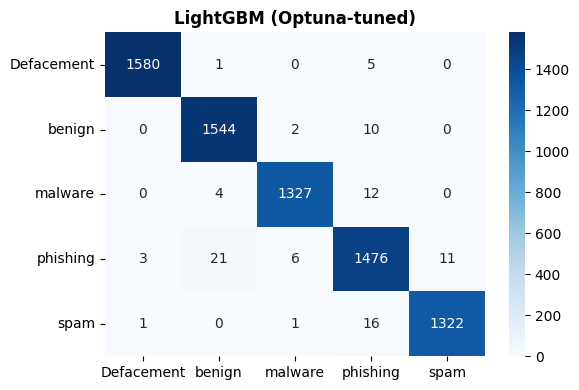

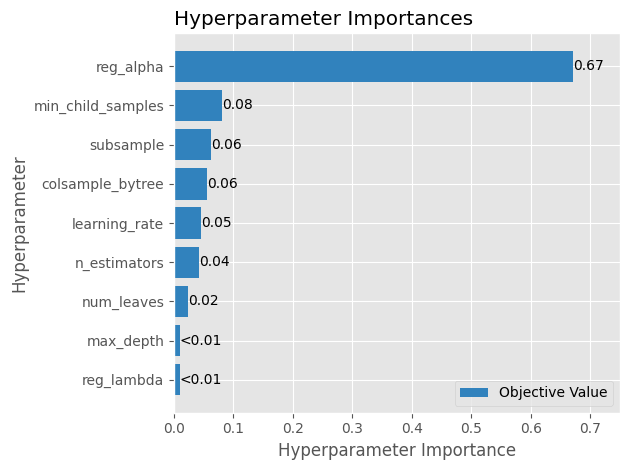

In [ ]:
# Retrain with best params on full training data
best_lgbm = LGBMClassifier(
    **study.best_params,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    verbose=-1
)
best_lgbm.fit(X_tr_sm, y_tr_sm)

y_pred_tuned = best_lgbm.predict(X_test_sc)
y_prob_tuned = best_lgbm.predict_proba(X_test_sc)

eval_model('LightGBM (Optuna-tuned)', y_test, y_pred_tuned, y_prob_tuned)

# Optuna visualisation
fig = optuna.visualization.matplotlib.plot_param_importances(study)
plt.tight_layout(); plt.show()

## 4 · Binary Specialist Ensemble

Train one RF per attack class (one-vs-rest). The output probabilities of each specialist become extra features for a meta-classifier.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ── 4a. Train one binary RF per class ──
specialist_proba_train = np.zeros((X_tr_sm.shape[0], n_classes))
specialist_proba_test  = np.zeros((X_test_sc.shape[0], n_classes))
specialists = {}

for c in range(n_classes):
    y_bin_tr = (y_tr_sm == c).astype(int)
    spec = RandomForestClassifier(n_estimators=100, n_jobs=-1, class_weight='balanced',
                                   random_state=c)
    spec.fit(X_tr_sm, y_bin_tr)
    specialist_proba_train[:, c] = spec.predict_proba(X_tr_sm)[:, 1]
    specialist_proba_test[:, c]  = spec.predict_proba(X_test_sc)[:, 1]
    specialists[c] = spec
    print(f'  Specialist [{label_map[c]:15s}] trained.')

print('\nAll specialist models trained.')

  Specialist [Defacement     ] trained.
  Specialist [benign         ] trained.
  Specialist [malware        ] trained.
  Specialist [phishing       ] trained.
  Specialist [spam           ] trained.

All specialist models trained.



  Binary Specialist Meta-Ensemble
  Accuracy : 0.9807  Macro F1 : 0.9810
  Macro FPR: 0.0049  ROC-AUC  : 0.9985


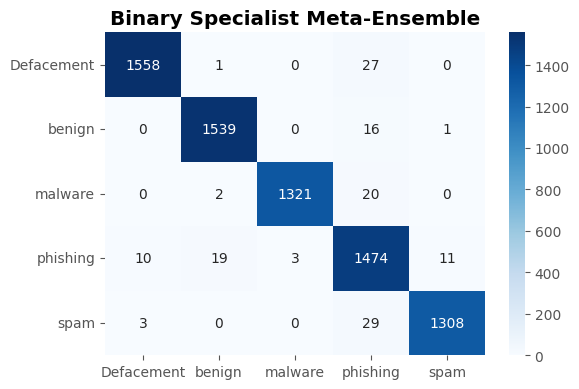

0.9806592209207301

In [ ]:
# ── 4b. Augment features with specialist scores ──
X_tr_aug   = np.hstack([X_tr_sm, specialist_proba_train])
X_test_aug = np.hstack([X_test_sc, specialist_proba_test])

# ── 4c. Meta-learner: tuned LightGBM on augmented features ──
meta = LGBMClassifier(
    **study.best_params,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    verbose=-1
)
meta.fit(X_tr_aug, y_tr_sm)

y_pred_meta = meta.predict(X_test_aug)
y_prob_meta = meta.predict_proba(X_test_aug)

eval_model('Binary Specialist Meta-Ensemble', y_test, y_pred_meta, y_prob_meta)

## 5 · Stacking Ensemble

Level-0 base learners: RF, XGBoost, LightGBM (tuned). Level-1 meta-learner: Logistic Regression.

Training stacking ensemble (may take a few minutes)...

  Stacking Ensemble (RF+XGB+LGBM → LR)
  Accuracy : 0.9872  Macro F1 : 0.9873
  Macro FPR: 0.0032  ROC-AUC  : 0.9994


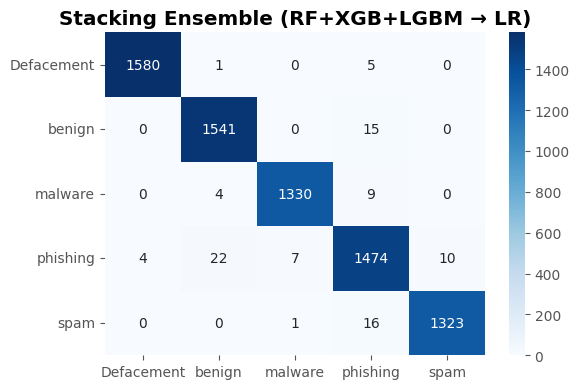

0.9871969490602016

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [
    ('rf',   RandomForestClassifier(n_estimators=200, n_jobs=-1, class_weight='balanced', random_state=42)),
    ('xgb',  xgb),
    ('lgbm', best_lgbm),
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, C=1.0, multi_class='multinomial'),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=True   # also pass raw features to meta-learner
)

print('Training stacking ensemble (may take a few minutes)...')
stack.fit(X_tr_sm, y_tr_sm)

y_pred_stack = stack.predict(X_test_sc)
y_prob_stack = stack.predict_proba(X_test_sc)

eval_model('Stacking Ensemble (RF+XGB+LGBM → LR)', y_test, y_pred_stack, y_prob_stack)

## 7 · Champion Model Comparison


🏆 FINAL LEADERBOARD
                                      Accuracy  Macro F1  Macro FPR  ROC-AUC
LightGBM                                0.9873    0.9874     0.0032   0.9996
LightGBM (Optuna-tuned)                 0.9873    0.9874     0.0032   0.9996
Stacking Ensemble (RF+XGB+LGBM → LR)    0.9872    0.9873     0.0032   0.9994
Weighted Soft Voting (RF+XGB+LGBM)      0.9867    0.9867     0.0034   0.9995
XGBoost                                 0.9837    0.9838     0.0041   0.9995
Binary Specialist Meta-Ensemble         0.9807    0.9810     0.0049   0.9985
Random Forest                           0.9752    0.9755     0.0062   0.9990
Decision Tree                           0.9516    0.9517     0.0121   0.9758
Logistic Regression                     0.8001    0.7991     0.0501   0.9591
SVM (Linear)                            0.7700    0.7655     0.0576   0.9478
AdaBoost                                0.7126    0.7067     0.0718   0.8930


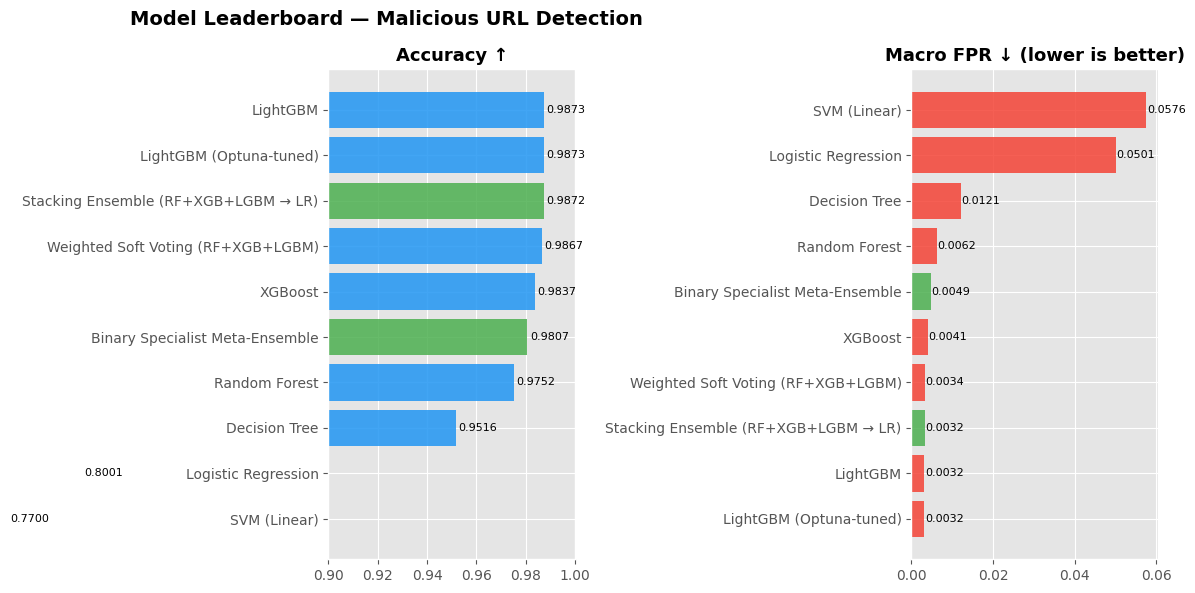

In [ ]:
# Load ML results from Notebook 2
try:
    prev_ml = pd.read_csv(MODEL_DIR + 'ml_results.csv', index_col=0)
    for idx, row in prev_ml.iterrows():
        all_results[idx] = row.to_dict()
except FileNotFoundError:
    print('ml_results.csv not found — run Notebook 2 first')

final_df = pd.DataFrame(all_results).T[['Accuracy', 'Macro F1', 'Macro FPR', 'ROC-AUC']]
final_df = final_df.sort_values('Accuracy', ascending=False)
print('\n🏆 FINAL LEADERBOARD')
print(final_df.round(4).to_string())
final_df.to_csv(MODEL_DIR + 'final_leaderboard.csv')

# ── Leaderboard chart ──
top_n = min(10, len(final_df))
plot_df = final_df.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy (higher is better)
colors_acc = ['#4CAF50' if 'Ensemble' in n or 'Stacking' in n or 'Meta' in n else '#2196F3'
               for n in plot_df.index]
axes[0].barh(plot_df.index[::-1], plot_df['Accuracy'][::-1], color=colors_acc[::-1], alpha=0.85)
axes[0].set_title('Accuracy ↑', fontweight='bold', fontsize=13)
axes[0].set_xlim(0.9, 1.0)
for i, v in enumerate(plot_df['Accuracy'][::-1]):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)

# FPR (lower is better)
plot_fpr = final_df.head(top_n).sort_values('Macro FPR')
colors_fpr = ['#4CAF50' if 'Ensemble' in n or 'Stacking' in n or 'Meta' in n else '#F44336'
               for n in plot_fpr.index]
axes[1].barh(plot_fpr.index, plot_fpr['Macro FPR'], color=colors_fpr, alpha=0.85)
axes[1].set_title('Macro FPR ↓ (lower is better)', fontweight='bold', fontsize=13)
for i, v in enumerate(plot_fpr['Macro FPR']):
    axes[1].text(v + 0.0001, i, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Model Leaderboard — Malicious URL Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(MODEL_DIR + 'final_leaderboard.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 · Save Champion Model

In [ ]:
import json

champion_name = final_df.index[0]
print(f'🥇 Champion: {champion_name}')

# Map champion name to model object
model_registry = {
    'LightGBM (Optuna-tuned)'              : best_lgbm,
    'Binary Specialist Meta-Ensemble'      : meta,
    'Stacking Ensemble (RF+XGB+LGBM → LR)': stack,
}
champion_model = model_registry.get(champion_name)

if champion_model is not None:
    with open(MODEL_DIR + 'champion_model.pkl', 'wb') as f:
        pickle.dump({
            'model'       : champion_model,
            'scaler'      : scaler,
            'label_map'   : label_map,
            'champion_name': champion_name
        }, f)
    print(f'✅ Champion saved to {MODEL_DIR}champion_model.pkl')

# Save specialist models too (for Notebook 5 demo)
with open(MODEL_DIR + 'specialists.pkl', 'wb') as f:
    pickle.dump(specialists, f)

print('\n=== FINAL SUMMARY ===')
best_row = final_df.iloc[0]
print(f'Champion       : {champion_name}')
print(f'Accuracy       : {best_row["Accuracy"]:.4f}')
print(f'Macro F1       : {best_row["Macro F1"]:.4f}')
print(f'Macro FPR      : {best_row["Macro FPR"]:.4f}')
print(f'ROC-AUC        : {best_row["ROC-AUC"]:.4f}' if best_row['ROC-AUC'] else '')

🥇 Champion: LightGBM

=== FINAL SUMMARY ===
Champion       : LightGBM
Accuracy       : 0.9873
Macro F1       : 0.9874
Macro FPR      : 0.0032
ROC-AUC        : 0.9996
